# Vision Transformer for AI-Generated Face Detection

**Objectives:**
1. Train a ViT classifier on real vs AI-generated faces
2. Achieve competitive classification accuracy
3. Generate Grad-CAM visualizations to understand attention patterns
4. Generate Attention Rollout visualizations to understand attention patterns

## 1. Setup & Configuration

### Imports and Device Configuration

In [1]:
# ===== Standard Library =====
import os
import json
import random
import logging
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Tuple

# ===== Third-Party Libraries =====
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from tqdm import tqdm

# ===== Scikit-learn Metrics =====
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
)

# ===== PyTorch =====
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split

# ===== Torchvision =====
import torchvision
from torchvision import transforms

# ===== Custom Modules =====
from vit_helpers.vit_data_utils import *
from vit_helpers.vit_model import *
from vit_helpers.vit_gradcam import *
from vit_helpers.vit_attention_rollout import *

# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Create output directories
os.makedirs('./vit_checkpoints', exist_ok=True)
os.makedirs('./vit_results', exist_ok=True)
os.makedirs('./vit_visualizations', exist_ok=True)
os.makedirs('./vit_model_outputs', exist_ok=True)


print("✓ Setup complete")

Using device: cuda
✓ Setup complete


## 2. Configuration & Data Loading

### Paths and Hyperparameters

In [2]:
# ============================================================================
# Configuration
# ============================================================================

# Dataset paths
DATA_SOURCE_PATH = './data/source'  # Raw data: real/ and fake/ subdirectories
DATASET_PATH = './data/dataset'     # Pre-organized: train/, val/, test/ splits
CHECKPOINT_DIR = './vit_checkpoints'

# Data loading
BATCH_SIZE = 128
NUM_WORKERS = 4
IMAGE_SIZE = 224

# Analysis parameters
MAX_SAMPLES_FOR_ANALYSIS = 1000  # Limit samples for attention analysis to speed up computation
NUM_ATTENTION_EXAMPLES = 4       # Number of examples to visualize in comparisons

print("Configuration loaded successfully")

Configuration loaded successfully


In [3]:
# ============================================================================
# Load Datasets
# ============================================================================
print("\n" + "="*70)
print("LOADING DATASET")
print("="*70)

try:
    print(f"Loading from: {DATASET_PATH}")
    train_loader, val_loader, test_loader = create_dataloaders(
        dataset_root=DATASET_PATH,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        image_size=IMAGE_SIZE
    )
    print("✓ Data loaders created successfully")
    
    # Display statistics
    print(f"\n{'Split':<15} {'Samples':<12} {'Batch Size':<12}")
    print("-" * 39)
    print(f"{'Train':<15} {len(train_loader.dataset):<12} {BATCH_SIZE:<12}")
    print(f"{'Validation':<15} {len(val_loader.dataset):<12} {BATCH_SIZE:<12}")
    print(f"{'Test':<15} {len(test_loader.dataset):<12} {BATCH_SIZE:<12}")
    print(f"{'Total':<15} {len(train_loader.dataset) + len(val_loader.dataset) + len(test_loader.dataset):<12}")
    
    # Show sample batch shape
    images, labels = next(iter(train_loader))
    print(f"\nSample batch shape: {images.shape}")
    real_count = (labels == 0).sum().item()
    fake_count = (labels == 1).sum().item()
    print(f"Sample batch distribution: {real_count} real, {fake_count} AI-generated")
    print(f"Label mapping: 0=Real, 1=AI-Generated\n")
    
except Exception as e:
    print(f"✗ Error loading data: {e}")
    import traceback
    traceback.print_exc()

INFO:vit_helpers.vit_data_utils:Loaded 72574 images for train split



LOADING DATASET
Loading from: ./data/dataset


INFO:vit_helpers.vit_data_utils:Loaded 24190 images for val split
INFO:vit_helpers.vit_data_utils:Loaded 24190 images for test split


✓ Data loaders created successfully

Split           Samples      Batch Size  
---------------------------------------
Train           72574        128         
Validation      24190        128         
Test            24190        128         
Total           120954      

Sample batch shape: torch.Size([128, 3, 224, 224])
Sample batch distribution: 77 real, 51 AI-generated
Label mapping: 0=Real, 1=AI-Generated



## 3. Model Setup

**Vision Transformer (ViT-Base) Architecture:**
- Input: 224×224 RGB images
- Patches: 16×16 (196 patches per image)
- Encoder: 12 transformer blocks with multi-head self-attention
- Classification head: Adapted for binary classification (real vs AI-generated)

In [4]:
# ============================================================================
# Initialize Vision Transformer Model
# ============================================================================
print("\n" + "="*70)
print("INITIALIZING VISION TRANSFORMER")
print("="*70)

try:
    vit_model = ViTFaceDetector(
        model_name='vit_base_patch16_224',
        pretrained=True
    )
    print("✓ ViT model initialized successfully")
    
    # Count parameters
    total_params = sum(p.numel() for p in vit_model.parameters())
    trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
    print(f"\nModel Parameters:")
    print(f"  Total:     {total_params:>12,}")
    print(f"  Trainable: {trainable_params:>12,}")
    print(f"  Frozen:    {total_params - trainable_params:>12,}")
    
except Exception as e:
    print(f"✗ Error initializing model: {e}")
    import traceback
    traceback.print_exc()


INITIALIZING VISION TRANSFORMER


INFO:vit_helpers.vit_model:Initialized vit_base_patch16_224 with pretrained=True


✓ ViT model initialized successfully

Model Parameters:
  Total:       86,193,410
  Trainable:   86,193,410
  Frozen:               0


## 4. Training

**Training Configuration:**
- Loss function: Cross-Entropy Loss
- Optimizer: AdamW
- Learning rate: 1e-4 with cosine annealing
- Early stopping: Patience = 10 epochs
- Max epochs: 50

In [5]:
# ============================================================================
# Initialize Trainer and Train Model
# ============================================================================
print("\n" + "="*70)
print("TRAINING SETUP")
print("="*70)

# Training parameters
TRAIN_MODE = True # Set to True to enable training
NUM_EPOCHS = 1

# Initialize trainer
trainer = ViTTrainer(
    model=vit_model,
    device=device,
    learning_rate=1e-4,
    weight_decay=1e-5
)
print("✓ Trainer initialized")

if TRAIN_MODE:
    print("\n" + "="*70)
    print("STARTING TRAINING")
    print("="*70)
    
    try:
        history = trainer.train(
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=NUM_EPOCHS,
            checkpoint_dir=CHECKPOINT_DIR
        )
        print("\n✓ Training completed successfully")
    except Exception as e:
        print(f"\n✗ Error during training: {e}")
        import traceback
        traceback.print_exc()
else:
    # Try to load pre-trained checkpoint
    best_checkpoint_pattern = os.path.join(CHECKPOINT_DIR, "best_model_*.pth")
    checkpoints = list(Path(CHECKPOINT_DIR).glob("best_model_*.pth"))
    
    if checkpoints:
        latest_checkpoint = max(checkpoints, key=os.path.getctime)
        try:
            trainer.load_checkpoint(str(latest_checkpoint))
            print(f"✓ Loaded pre-trained model from {latest_checkpoint.name}")
        except Exception as e:
            print(f"⚠ Warning: Could not load checkpoint: {e}")
            print("  Using model in current state")
    else:
        print("⚠ No pre-trained checkpoint found")
        print("  Using randomly initialized model for evaluation")

/courses/CS7150.202630/students/wu.hans/deepface_insight/vit_helpers/vit_model.py:131: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler()
INFO:vit_helpers.vit_model:Trainer initialized on device: cuda
INFO:vit_helpers.vit_model:
Epoch 1/1



TRAINING SETUP
✓ Trainer initialized

STARTING TRAINING


Training:   0%|          | 0/567 [00:00<?, ?it/s]/courses/CS7150.202630/students/wu.hans/deepface_insight/vit_helpers/vit_model.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validating: 100%|██████████| 189/189 [01:26<00:00,  2.18it/s, loss=0.108, acc=95.9]  
INFO:vit_helpers.vit_model:Train Loss: 0.2459, Train Acc: 89.68% | Val Loss: 0.1128, Val Acc: 95.90%
INFO:vit_helpers.vit_model:Saved best model with val_acc: 95.90%



✓ Training completed successfully


## Training Loss and Accuracy Visualization

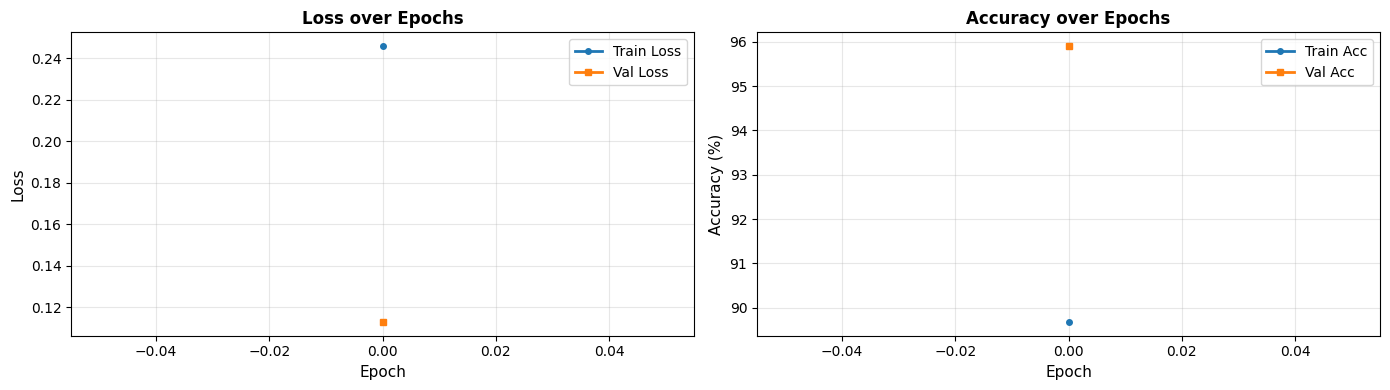


Best validation accuracy: 95.90%
✓ Saved to ./vit_model_outputs/training_history.png


In [6]:
# Plot training history if available
if 'history' in locals() and history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Loss curves
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=4)
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Loss', fontsize=11)
    axes[0].set_title('Loss over Epochs', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2, marker='o', markersize=4)
    axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2, marker='s', markersize=4)
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Accuracy (%)', fontsize=11)
    axes[1].set_title('Accuracy over Epochs', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./vit_model_outputs/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nBest validation accuracy: {max(history['val_acc']):.2f}%")
    print("✓ Saved to ./vit_model_outputs/training_history.png")
else:
    print("⚠ No training history available (model not trained in this session)")

## 5. Model Evaluation

Evaluate the trained ViT on the test set using multiple metrics and visualizations.


TEST SET EVALUATION

Evaluating on test set...


Testing: 100%|██████████| 189/189 [01:16<00:00,  2.48it/s]



Performance Metrics:
  Accuracy:   96.03%
  Precision:  96.03%
  Recall:     96.03%
  F1-Score:   96.03%

✓ Metrics saved to ./vit_results/test_metrics.json


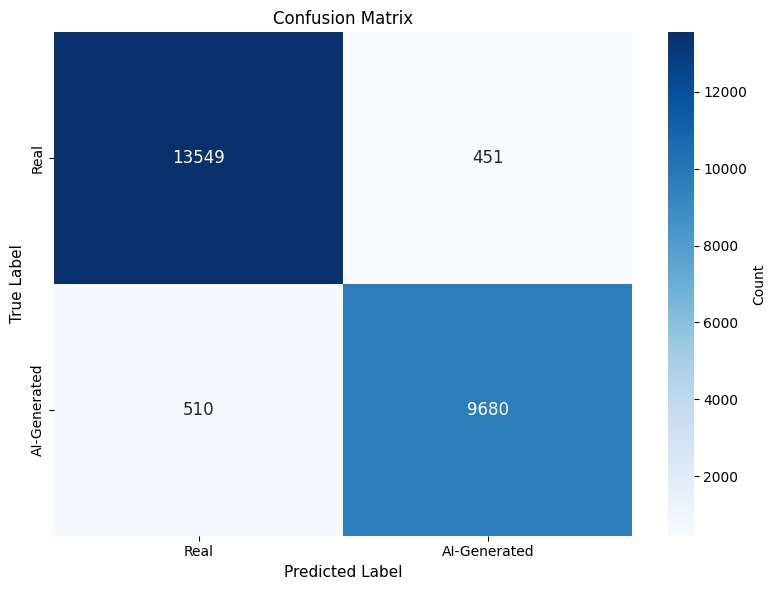

✓ Saved to ./vit_model_outputs/confusion_matrix.png


In [7]:
# ============================================================================
# Evaluate Model on Test Set
# ============================================================================
print("\n" + "="*70)
print("TEST SET EVALUATION")
print("="*70)

try:
    # Evaluate on test set
    print("\nEvaluating on test set...")
    test_results = trainer.evaluate(test_loader)
    
    # Compute metrics
    y_true = test_results['ground_truth']
    y_pred = test_results['predictions']
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    
    # Print metrics
    print("\nPerformance Metrics:")
    print(f"  Accuracy:  {accuracy*100:>6.2f}%")
    print(f"  Precision: {precision*100:>6.2f}%")
    print(f"  Recall:    {recall*100:>6.2f}%")
    print(f"  F1-Score:  {f1*100:>6.2f}%")
    
    # Save metrics
    metrics_dict = {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'confusion_matrix': cm.tolist()
    }
    
    with open('./vit_results/test_metrics.json', 'w') as f:
        json.dump(metrics_dict, f, indent=2)
    print("\n✓ Metrics saved to ./vit_results/test_metrics.json")
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Real', 'AI-Generated'],
                yticklabels=['Real', 'AI-Generated'],
                cbar_kws={'label': 'Count'},
                annot_kws={'fontsize': 12})
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label', fontsize=11)
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('./vit_model_outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved to ./vit_model_outputs/confusion_matrix.png")
    
except Exception as e:
    print(f"✗ Error during evaluation: {e}")
    import traceback
    traceback.print_exc()

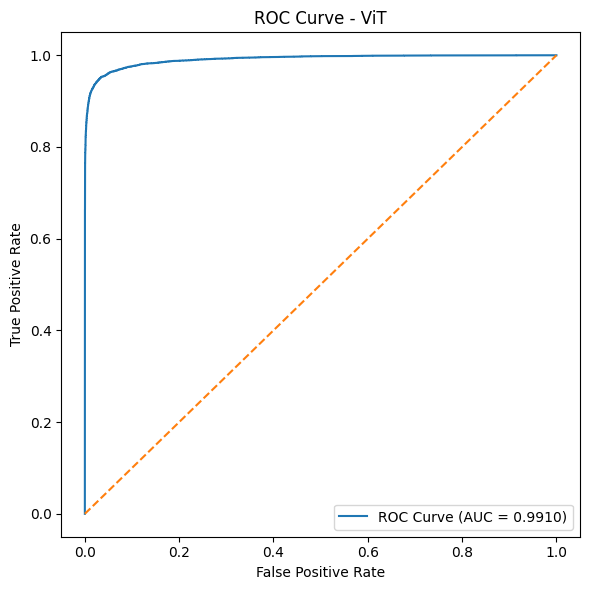

In [8]:
# ROC


all_probs = []
all_labels = []

vit_model.eval()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)

        outputs = vit_model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of "fake"

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())


fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ViT")
plt.legend()

plt.tight_layout()
plt.savefig("vit_model_outputs/roc_curve.png", dpi=300)
plt.show()